## Лабораторна робота №4

**Виконали:**   
   
Варіант 2
- Сачек Владислава, КА-31
- Богданова Олександра, КА-32
- Плахтій Злата, КА-32

**Хід виконання роботи:**
1. Завантажити два набори зображень згiдно з варiантом: чорно-бiлi (дивiться попереднiй практикум) та кольоровi. Якщо набiр великого розмiру, можна обрати частину.
2. Пiдготувати данi для навчання - за необхiдностi.
3. Роздiлити данi на навчальну, перевiрочну i тестову пiдмножини.
4. Побудувати i навчити базову модель з одним згортковим шаром. Оцiнити правильнiсть (accuracy) та точнiсть моделi на тренувальнiй i перевiрочнiй множинах.
5. Дослiдити рiзнi значення параметрiв padding i strides згорткового шару базової моделi, а також розмiрнiсть ядра (kernel) згортки та їх вплив на точнiсть моделi. На перевiрочнiй множинi обрати значення вказаних параметрiв.
6. Дослiдити кiлька альтернативних архiтектур згорткових моделей, якi включають:
- кiлька згорткових шарiв,
- шар/ шари нормалiзацiї за мiнi-батчами,
- шар/ шари дропауту.   
На перевiрочнiй множинi оцiнити якiсть побудованих моделей i обрати найкращу архiтектуру. Використати показники якостi: accuracy, precision, recall, f1-score, AUC.
7. Чи впливає на правильнiсть (accuracy) моделi додавання регуляризацiї: дропаут, рання зупинка навчання, та використання рiзних методiв iнiцiалiзацiї ваг?
8. Вiдобразити у TensorBoard графiки, якi iлюструють оцiнки якостi навчання мереж на навчальнiй та перевiрочнiй множинах:
- графiки змiни функцiї втрат на тренувальнiй i перевiрочнiй множинах по мiрi навчання моделей,
- графiки змiни правильностi моделi на тренувальнiй i перевiрочнiй множинах по мiрi навчання моделей.
9. Розрахувати на тестовiй множинi оцiнки якостi обраної найкращої моделi.
10. Завантажити зображення тестової множини i розпiзнати його навченими моделями.
11. Порiвняти побудованi згортковi моделi та багатошаровий персептрон в задачi класифiкацiї чорно-бiлих та кольорових зображень. Виконати класифікацію кольорових зображень також багатошаровим персептроном. 
Експериментальним шляхом показати що згорткові моделі, дійсно, краще за MLP виконують їх класифікацію.
Чорно-білі зображення (з практикуму 2) згортковою моделлю - по бажанню.
12. Зробити висновки щодо якостi класифiкацiї на основi побудованих моделей.

**Набір даних:** Rice Image Dataset (кольорові зображення)

### Імпорт бібліотек

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization, Input)

### Завантаження набору кольорових зображень Rice Image Dataset

In [2]:
DATA_DIR = "./Rice_Image_Dataset"

IMG_SIZE = 64
BATCH_SIZE = 64

### Підготовка даних та розділення на навчальну, перевiрочну i тестову пiдмножини

Набір містить 75 000 кольорових зображень зерен рису п'яти сортів **Arborio**, **Basmati**, **Ipsala**, **Jasmine**, **Karacadag**.    
Нехай розділення: 
- **train (60%)** - навчальна множина
- **val (20%)** - перевірочна множина
- **test (20%)** - тестова множина

Завантаження виконуємо за допомогою tf.keras.utils.image_dataset_from_directory, що автоматично зчитує зображення з підпапок, формує мітки за іменами папок та групує дані в батчі по 64. 

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, label_mode="categorical",
    validation_split=0.4, subset="training", seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, label_mode="categorical",
    validation_split=0.4, subset="validation", seed=42
)

val_batches = len(val_ds)
test_size = val_batches // 2

test_ds = val_ds.skip(test_size)
val_ds  = val_ds.take(test_size)

CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)
print(f"Класи: {CLASS_NAMES}")
print(f"Кількість класів: {NUM_CLASSES}")
print(f"Train батчів: {len(train_ds)}, Val батчів: {len(val_ds)}, Test батчів: {len(test_ds)}")

Found 75000 files belonging to 5 classes.
Using 45000 files for training.
Found 75000 files belonging to 5 classes.
Using 30000 files for validation.
Класи: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']
Кількість класів: 5
Train батчів: 704, Val батчів: 234, Test батчів: 235


In [4]:
train_ds = train_ds.take(len(train_ds) // 3)
val_ds   = val_ds.take(len(val_ds) // 3)
test_ds  = test_ds.take(len(test_ds) // 3)

print(f"Після скорочення: Train батчів: {len(train_ds)}, "
      f"Val батчів: {len(val_ds)}, Test батчів: {len(test_ds)}")

Після скорочення: Train батчів: 234, Val батчів: 78, Test батчів: 78


Виконуємо нормалізацію пікселів до [0, 1] через шар `Rescaling` і для прискорення повторних епох застосовуємо .cache().prefetch():

In [5]:
# Нормалізація пікселів [0, 255] -> [0, 1]
normalization = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization(x), y))
test_ds  = test_ds.map(lambda x, y: (normalization(x), y))

# Оптимізація завантаження даних
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

### Візуалізація прикладів зображень

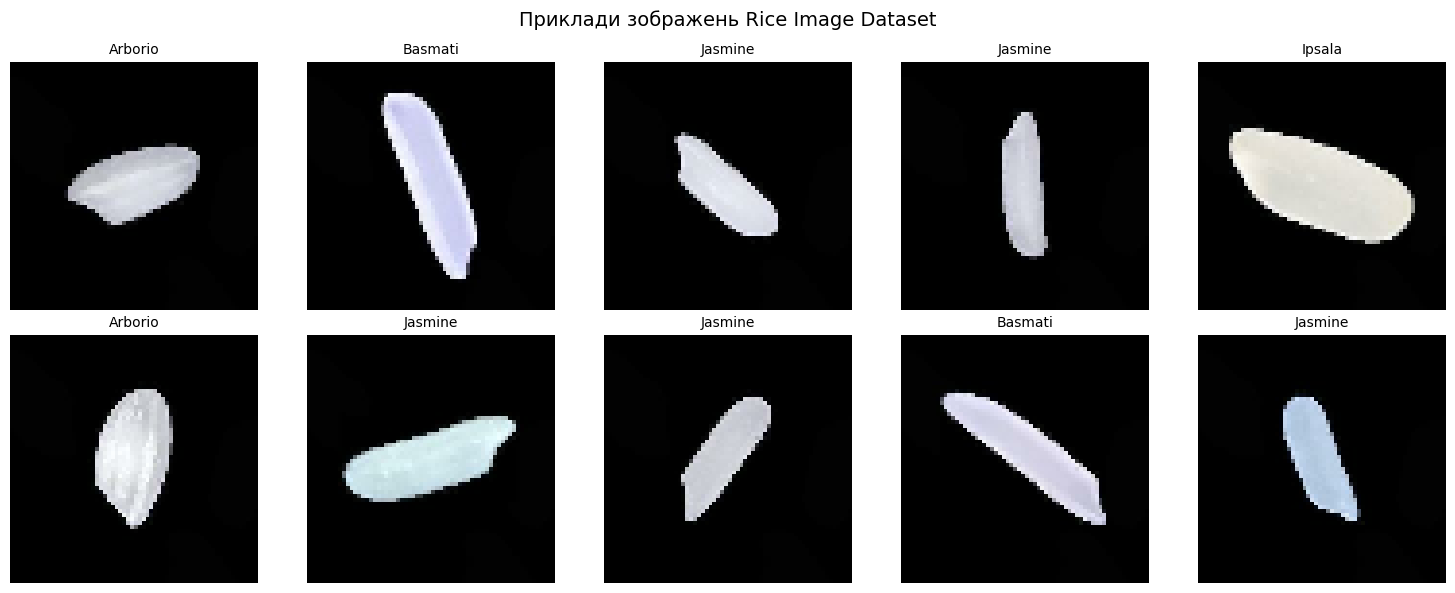

In [6]:
images, labels = next(iter(train_ds))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(10):
    ax = axes[i // 5, i % 5]
    ax.imshow(images[i].numpy())
    class_idx = np.argmax(labels[i])
    ax.set_title(CLASS_NAMES[class_idx], fontsize=10)
    ax.axis("off")
plt.suptitle("Приклади зображень Rice Image Dataset", fontsize=14)
plt.tight_layout()
plt.show()

### Базова модель з одним згортковим шаром
Побудуємо базову CNN з одним згортковим шаром: Input(64×64×3) -> Conv2D(32, 3×3, same, relu) -> MaxPooling2D(2×2) -> Flatten -> Dense(5, softmax). Модель навчається протягом 20 епох з оптимізатором Adam та функцією втрат categorical crossentropy.

In [7]:
EPOCHS = 20

def build_base_model(filters=32, kernel_size=(3,3), padding='same', strides=(1,1)):
    model = Sequential([
        Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        Conv2D(filters, kernel_size, padding=padding, strides=strides, activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

base_model = build_base_model()
base_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │       163,845 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,741 (643.52 KB)

 Trainable params: 164,741 (643.52 KB)

 Non-trainable params: 0 (0.00 B)

### Навчання базової моделі

In [8]:
history_base = base_model.fit(
    train_ds,
    epochs=EPOCHS, validation_data=val_ds, verbose=1
)

Epoch 1/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - accuracy: 0.9103 - loss: 0.2721 - val_accuracy: 0.9577 - val_loss: 0.1319
Epoch 2/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.9661 - loss: 0.1080 - val_accuracy: 0.9649 - val_loss: 0.1055
Epoch 3/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.9764 - loss: 0.0747 - val_accuracy: 0.9708 - val_loss: 0.0893
Epoch 4/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.9831 - loss: 0.0576 - val_accuracy: 0.9647 - val_loss: 0.1037
Epoch 5/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.9841 - loss: 0.0534 - val_accuracy: 0.9583 - val_loss: 0.1179
Epoch 6/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.9850 - loss: 0.0486 - val_accuracy: 0.9641 - val_loss: 0.0971
Epoch 7/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.9862 - loss: 0.0450 - val_accuracy: 0.9766 - val_loss: 0.0660
Epoch 8/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.9881 - loss: 0.0402 - val_acc

Модель демонструє ознаки незначного перенавчання: train accuracy зростає до майже 1.0, тоді як val accuracy стабілізується на рівні ~0.985.

### Графіки навчання базової моделі

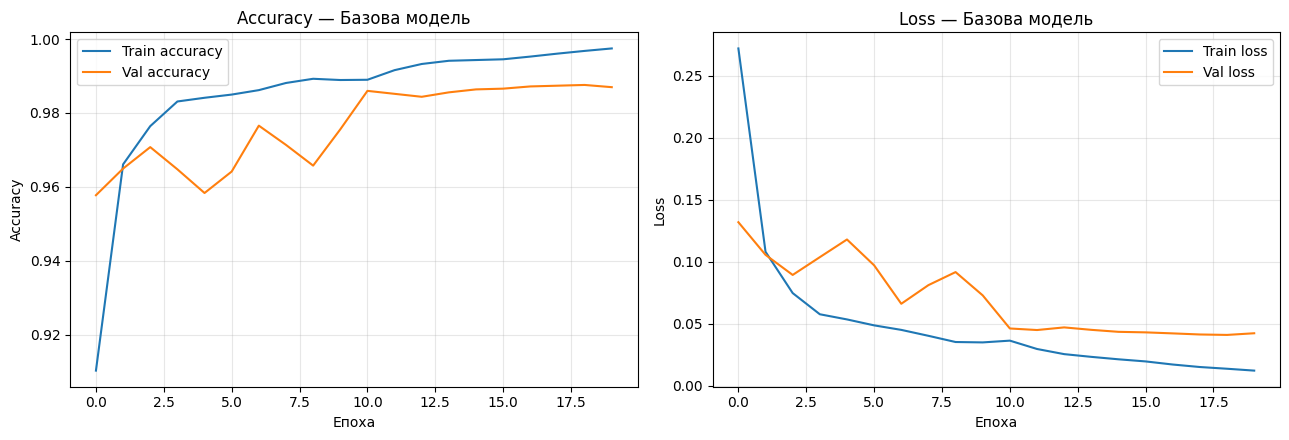

In [9]:
def plot_history(history, title=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

    ax1.plot(history.history['accuracy'], label='Train accuracy')
    ax1.plot(history.history['val_accuracy'], label='Val accuracy')
    ax1.set_xlabel('Епоха'); ax1.set_ylabel('Accuracy')
    ax1.set_title(f'Accuracy — {title}')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(history.history['loss'], label='Train loss')
    ax2.plot(history.history['val_loss'], label='Val loss')
    ax2.set_xlabel('Епоха'); ax2.set_ylabel('Loss')
    ax2.set_title(f'Loss — {title}')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history_base, "Базова модель")

### Оцінка базової моделі

In [10]:
train_loss, train_acc = base_model.evaluate(train_ds, verbose=0)
val_loss, val_acc = base_model.evaluate(val_ds, verbose=0)

print(f"Базова модель:")
print(f"  Train — loss: {train_loss:.4f}, accuracy: {train_acc:.4f}")
print(f"  Val   — loss: {val_loss:.4f}, accuracy: {val_acc:.4f}")

Базова модель:
  Train — loss: 0.0087, accuracy: 0.9977
  Val   — loss: 0.0422, accuracy: 0.9870


### Дослідження параметрів згорткового шару

Дослідимо вплив на якість моделі:
- **padding**: 'same' vs 'valid'
- **strides**: (1,1) vs (2,2)
- **kernel_size**: (3,3), (5,5), (7,7)

#### Вплив параметра padding


padding='same'
  Train acc: 0.9957, Val acc: 0.9816

padding='valid'
  Train acc: 0.9949, Val acc: 0.9832


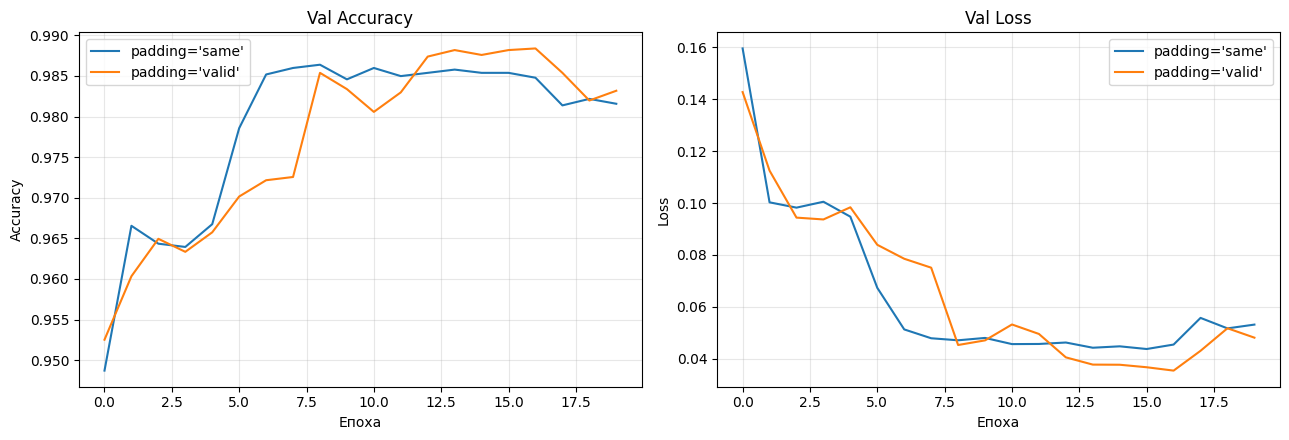

In [11]:
results = []

for pad in ['same', 'valid']:
    print(f"\npadding='{pad}'")
    model = build_base_model(padding=pad)
    hist = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds, verbose=0)
    t_loss, t_acc = model.evaluate(train_ds, verbose=0)
    v_loss, v_acc = model.evaluate(val_ds, verbose=0)
    results.append({
        'param': 'padding', 'value': pad,
        'train_acc': t_acc, 'val_acc': v_acc,
        'train_loss': t_loss, 'val_loss': v_loss,
        'history': hist
    })
    print(f"  Train acc: {t_acc:.4f}, Val acc: {v_acc:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
for r in results:
    ax1.plot(r['history'].history['val_accuracy'], label=f"padding='{r['value']}'")
    ax2.plot(r['history'].history['val_loss'], label=f"padding='{r['value']}'")
ax1.set_title('Val Accuracy'); ax1.set_xlabel('Епоха')
ax1.set_ylabel('Accuracy'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.set_title('Val Loss'); ax2.set_xlabel('Епоха')
ax2.set_ylabel('Loss'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

Padding valid, який зменшує просторову розмірність, показав дещо кращий результат на цьому наборі даних.

#### Вплив параметра strides


strides=(1, 1)
  Train acc: 0.9969, Val acc: 0.9854

strides=(2, 2)
  Train acc: 0.9931, Val acc: 0.9876


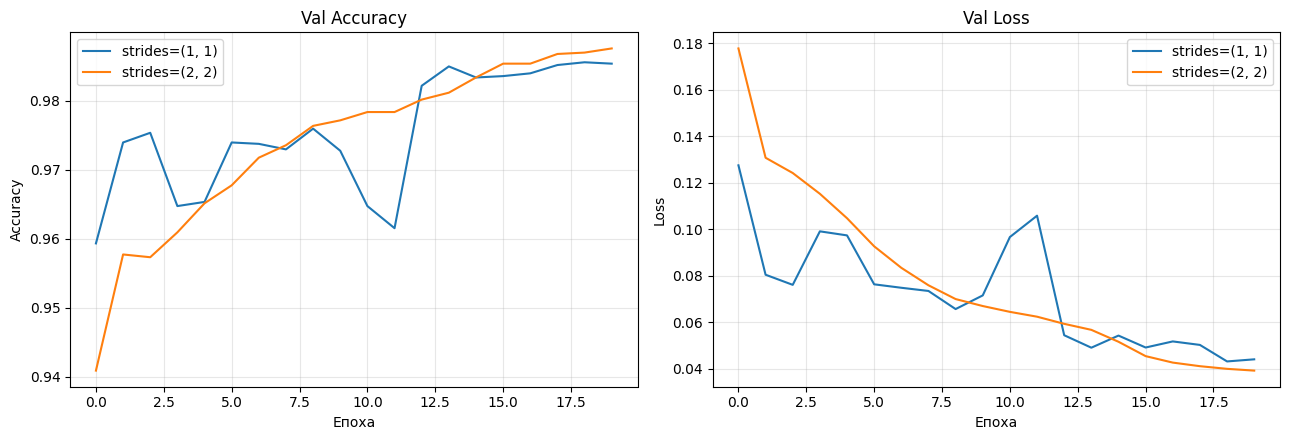

In [12]:
for stride in [(1,1), (2,2)]:
    print(f"\nstrides={stride}")
    model = build_base_model(strides=stride)
    hist = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds, verbose=0)
    t_loss, t_acc = model.evaluate(train_ds, verbose=0)
    v_loss, v_acc = model.evaluate(val_ds, verbose=0)
    results.append({
        'param': 'strides', 'value': str(stride),
        'train_acc': t_acc, 'val_acc': v_acc,
        'train_loss': t_loss, 'val_loss': v_loss,
        'history': hist
    })
    print(f"  Train acc: {t_acc:.4f}, Val acc: {v_acc:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
for r in results:
    if r['param'] == 'strides':
        ax1.plot(r['history'].history['val_accuracy'], label=f"strides={r['value']}")
        ax2.plot(r['history'].history['val_loss'], label=f"strides={r['value']}")
ax1.set_title('Val Accuracy'); ax1.set_xlabel('Епоха')
ax1.set_ylabel('Accuracy'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.set_title('Val Loss'); ax2.set_xlabel('Епоха')
ax2.set_ylabel('Loss'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

Збільшений крок (2,2) показав трохи вищу val accuracy, одночасно суттєво прискоривши навчання.

#### Вплив розмірності ядра


kernel_size=(3, 3)
  Train acc: 0.9978, Val acc: 0.9880

kernel_size=(5, 5)
  Train acc: 0.9961, Val acc: 0.9834

kernel_size=(7, 7)
  Train acc: 0.9960, Val acc: 0.9842


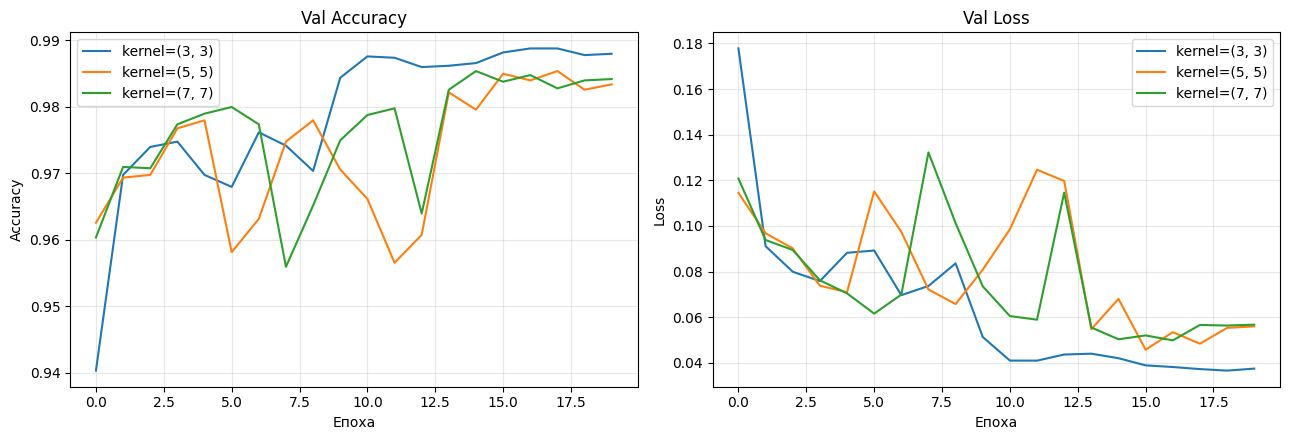

In [13]:
for ks in [(3,3), (5,5), (7,7)]:
    print(f"\nkernel_size={ks}")
    model = build_base_model(kernel_size=ks)
    hist = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds, verbose=0)
    t_loss, t_acc = model.evaluate(train_ds, verbose=0)
    v_loss, v_acc = model.evaluate(val_ds, verbose=0)
    results.append({
        'param': 'kernel_size', 'value': str(ks),
        'train_acc': t_acc, 'val_acc': v_acc,
        'train_loss': t_loss, 'val_loss': v_loss,
        'history': hist
    })
    print(f"  Train acc: {t_acc:.4f}, Val acc: {v_acc:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
for r in results:
    if r['param'] == 'kernel_size':
        ax1.plot(r['history'].history['val_accuracy'], label=f"kernel={r['value']}")
        ax2.plot(r['history'].history['val_loss'], label=f"kernel={r['value']}")
ax1.set_title('Val Accuracy'); ax1.set_xlabel('Епоха')
ax1.set_ylabel('Accuracy'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.set_title('Val Loss'); ax2.set_xlabel('Епоха')
ax2.set_ylabel('Loss'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

Найменше ядро 3×3 показало найкращий результат, зі збільшенням розміру ядра якість поступово знижується.

In [14]:
import pandas as pd

rows = []
for r in results:
    rows.append({
        'Параметр': r['param'],
        'Значення': r['value'],
        'Train Accuracy': f"{r['train_acc']:.4f}",
        'Val Accuracy': f"{r['val_acc']:.4f}",
        'Train Loss': f"{r['train_loss']:.4f}",
        'Val Loss': f"{r['val_loss']:.4f}",
    })

df_results = pd.DataFrame(rows)
display(df_results)

print("\nНайкраща конфігурація за Val Accuracy по кожному параметру:")
for param in ['padding', 'strides', 'kernel_size']:
    subset = df_results[df_results['Параметр'] == param]
    best_idx = subset['Val Accuracy'].astype(float).idxmax()
    best = df_results.iloc[best_idx]
    print(f"{best['Параметр']} = {best['Значення']}, Val Accuracy = {best['Val Accuracy']}")

,Параметр,Значення,Train Accuracy,Val Accuracy,Train Loss,Val Loss
0,padding,same,0.9957,0.9816,0.0134,0.0531
1,padding,valid,0.9949,0.9832,0.0160,0.0481
2,strides,"(1, 1)",0.9969,0.9854,0.0110,0.0440
3,strides,"(2, 2)",0.9931,0.9876,0.0224,0.0392
4,kernel_size,"(3, 3)",0.9978,0.9880,0.0084,0.0374
5,kernel_size,"(5, 5)",0.9961,0.9834,0.0117,0.0560
6,kernel_size,"(7, 7)",0.9960,0.9842,0.0105,0.0567



Найкраща конфігурація за Val Accuracy по кожному параметру:
padding = valid, Val Accuracy = 0.9832
strides = (2, 2), Val Accuracy = 0.9876
kernel_size = (3, 3), Val Accuracy = 0.9880


#### Найкраща базова модель з обраними параметрами

На основі проведених експериментів обираємо найкращі значення параметрів та навчаємо фінальну базову модель.

Обрані параметри: padding='valid', strides=(2, 2), kernel_size=(3, 3)
Epoch 1/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8787 - loss: 0.3643 - val_accuracy: 0.9479 - val_loss: 0.1638
Epoch 2/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9577 - loss: 0.1369 - val_accuracy: 0.9581 - val_loss: 0.1249
Epoch 3/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9667 - loss: 0.1052 - val_accuracy: 0.9639 - val_loss: 0.1106
Epoch 4/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9722 - loss: 0.0871 - val_accuracy: 0.9665 - val_loss: 0.1040
Epoch 5/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9761 - loss: 0.0756 - val_accuracy: 0.9669 - val_loss: 0.0984
Epoch 6/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9794 - loss: 0.0678 - val_accuracy: 0.9692 - val_loss: 0.0890
Epoch 7/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9810 - loss: 0.0624 - val_accuracy: 0.9746 - val_loss: 0.0762
Epoch 8/20
234/234 ━━━━━━━━━━━━━━━

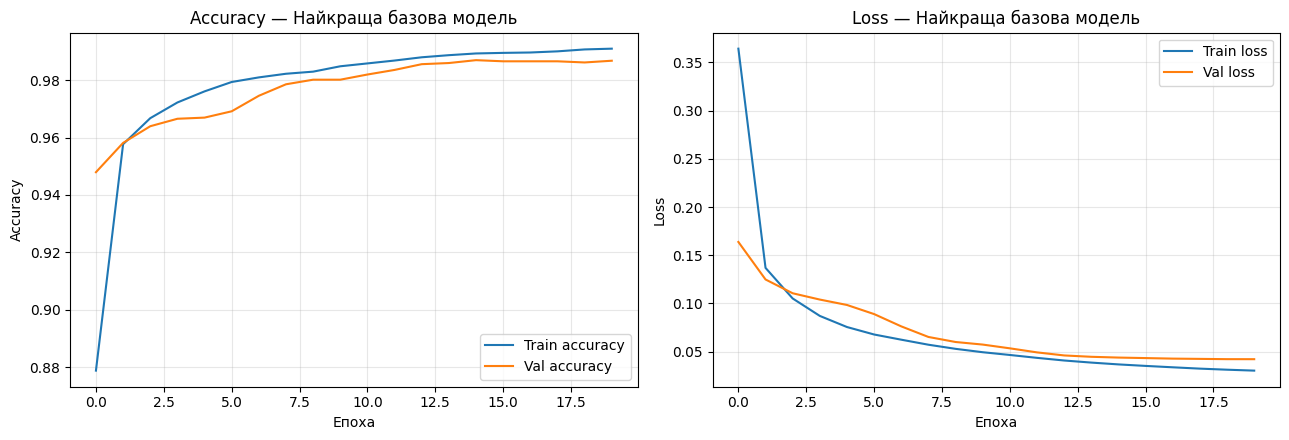


Найкраща базова модель — Val accuracy: 0.9868, Val loss: 0.0422


In [15]:
BEST_PADDING = 'valid'
BEST_STRIDES = (2, 2)
BEST_KERNEL  = (3, 3)

print(f"Обрані параметри: padding='{BEST_PADDING}', "
      f"strides={BEST_STRIDES}, kernel_size={BEST_KERNEL}")

best_base_model = build_base_model(
    padding=BEST_PADDING, strides=BEST_STRIDES, kernel_size=BEST_KERNEL
)

history_best_base = best_base_model.fit(
    train_ds,
    epochs=EPOCHS, validation_data=val_ds, verbose=1
)

plot_history(history_best_base, "Найкраща базова модель")

v_loss, v_acc = best_base_model.evaluate(val_ds, verbose=0)
print(f"\nНайкраща базова модель — Val accuracy: {v_acc:.4f}, Val loss: {v_loss:.4f}")

Даний датасет містить зображення зерен рису здебільшого дуже світлих відтінків на чорному фоні, тому padding='valid' і strides=(2,2) не погіршили результат, для таких однорідних зображень втрата деталей при зменшенні розмірності не критична.   
Моделі легко "запам'ятати" тренувальні приклади, бо відмінностей між зображеннями всередині класу мало, а між класами - нюанси форми та відтінку, тому у моделі є перенавчання, але незначне.

## Альтернативні архітектури CNN

In [16]:
from sklearn.metrics import classification_report
from tensorflow.keras.metrics import AUC


def compile_model(model):
    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            AUC(name='auc', multi_label=False)
        ]
    )
    return model

# Модель A: 2 Conv-блоки (без BN, без Dropout)
def build_model_A():
    model = Sequential([
        Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        Conv2D(32, (3,3), padding='same', activation='relu'),
        MaxPooling2D(2,2),
        Conv2D(64, (3,3), padding='same', activation='relu'),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(NUM_CLASSES, activation='softmax')
    ], name='ModelA_2conv')
    return compile_model(model)

# Модель B: 3 Conv-блоки + BatchNormalization
def build_model_B():
    model = Sequential([
        Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        Conv2D(32, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),
        Conv2D(64, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),
        Conv2D(128, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        Flatten(),
        Dense(256, activation='relu'),
        Dense(NUM_CLASSES, activation='softmax')
    ], name='ModelB_3conv_BN')
    return compile_model(model)

# Модель C: 2 Conv-блоки + BN + Dropout
def build_model_C():
    model = Sequential([
        Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        Conv2D(32, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),
        Dropout(0.25),
        Conv2D(64, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),
        Dropout(0.25),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ], name='ModelC_2conv_BN_Drop')
    return compile_model(model)

# Модель D: 3 Conv-блоки + BN + Dropout (найглибша)
def build_model_D():
    model = Sequential([
        Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        Conv2D(32, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),
        Dropout(0.2),
        Conv2D(64, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),
        Dropout(0.2),
        Conv2D(128, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ], name='ModelD_3conv_BN_Drop')
    return compile_model(model)


In [17]:

#  Навчання всіх моделей
architectures = {
    'A: 2Conv':          build_model_A,
    'B: 3Conv+BN':       build_model_B,
    'C: 2Conv+BN+Drop':  build_model_C,
    'D: 3Conv+BN+Drop':  build_model_D,
}

arch_histories = {}
arch_metrics   = {}


In [30]:
def get_metric(d, prefix):
    for k, v in d.items():
        if k == prefix or k.startswith(prefix):
            return v
    raise KeyError(f"Метрику '{prefix}' не знайдено серед: {list(d.keys())}")

arch_histories = {}
arch_metrics   = {}

for name, builder in architectures.items():
    print(f"\n{'='*55}\nНавчання: {name}\n{'='*55}")
    m = builder()
    hist = m.fit(
        train_ds,
        epochs=EPOCHS,
        validation_data=val_ds,
        verbose=1
    )
    arch_histories[name] = hist

    metrics_dict = m.evaluate(
        val_ds,
        verbose=0,
        return_dict=True
    )

    acc = get_metric(metrics_dict, 'accuracy')
    p   = get_metric(metrics_dict, 'precision')
    r   = get_metric(metrics_dict, 'recall')
    auc = get_metric(metrics_dict, 'auc')
    f1  = 2 * p * r / (p + r + 1e-8)

    arch_metrics[name] = {
        'accuracy': acc, 'precision': p,
        'recall': r, 'auc': auc, 'f1': f1
    }

    print(f"  Val accuracy : {acc:.4f}")
    print(f"  Val precision: {p:.4f}  recall: {r:.4f}  F1: {f1:.4f}")
    print(f"  Val AUC      : {auc:.4f}")


Навчання: A: 2Conv
Epoch 1/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - accuracy: 0.9310 - auc: 0.9933 - loss: 0.2054 - precision: 0.9484 - recall: 0.9157 - val_accuracy: 0.9609 - val_auc: 0.9969 - val_loss: 0.1180 - val_precision: 0.9609 - val_recall: 0.9607
Epoch 2/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 18s 75ms/step - accuracy: 0.9672 - auc: 0.9978 - loss: 0.0961 - precision: 0.9675 - recall: 0.9672 - val_accuracy: 0.9653 - val_auc: 0.9979 - val_loss: 0.0980 - val_precision: 0.9659 - val_recall: 0.9653
Epoch 3/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 17s 73ms/step - accuracy: 0.9741 - auc: 0.9985 - loss: 0.0761 - precision: 0.9742 - recall: 0.9740 - val_accuracy: 0.9704 - val_auc: 0.9985 - val_loss: 0.0853 - val_precision: 0.9705 - val_recall: 0.9704
Epoch 4/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 16s 68ms/step - accuracy: 0.9825 - auc: 0.9994 - loss: 0.0514 - precision: 0.9826 - recall: 0.9825 - val_accuracy: 0.9740 - val_auc: 0.9991 - val_loss: 0.0666 - val_precision: 0.9740 - val_recall: 0.9738
Epoc

,Модель,Accuracy,Precision,Recall,F1,AUC
0,A: 2Conv,0.9876,0.9876,0.9876,0.9876,0.9984
1,B: 3Conv+BN,0.9914,0.9914,0.9914,0.9914,0.9978
2,C: 2Conv+BN+Drop,0.9910,0.9910,0.9910,0.9910,0.9988
3,D: 3Conv+BN+Drop,0.9912,0.9914,0.9912,0.9913,0.9983


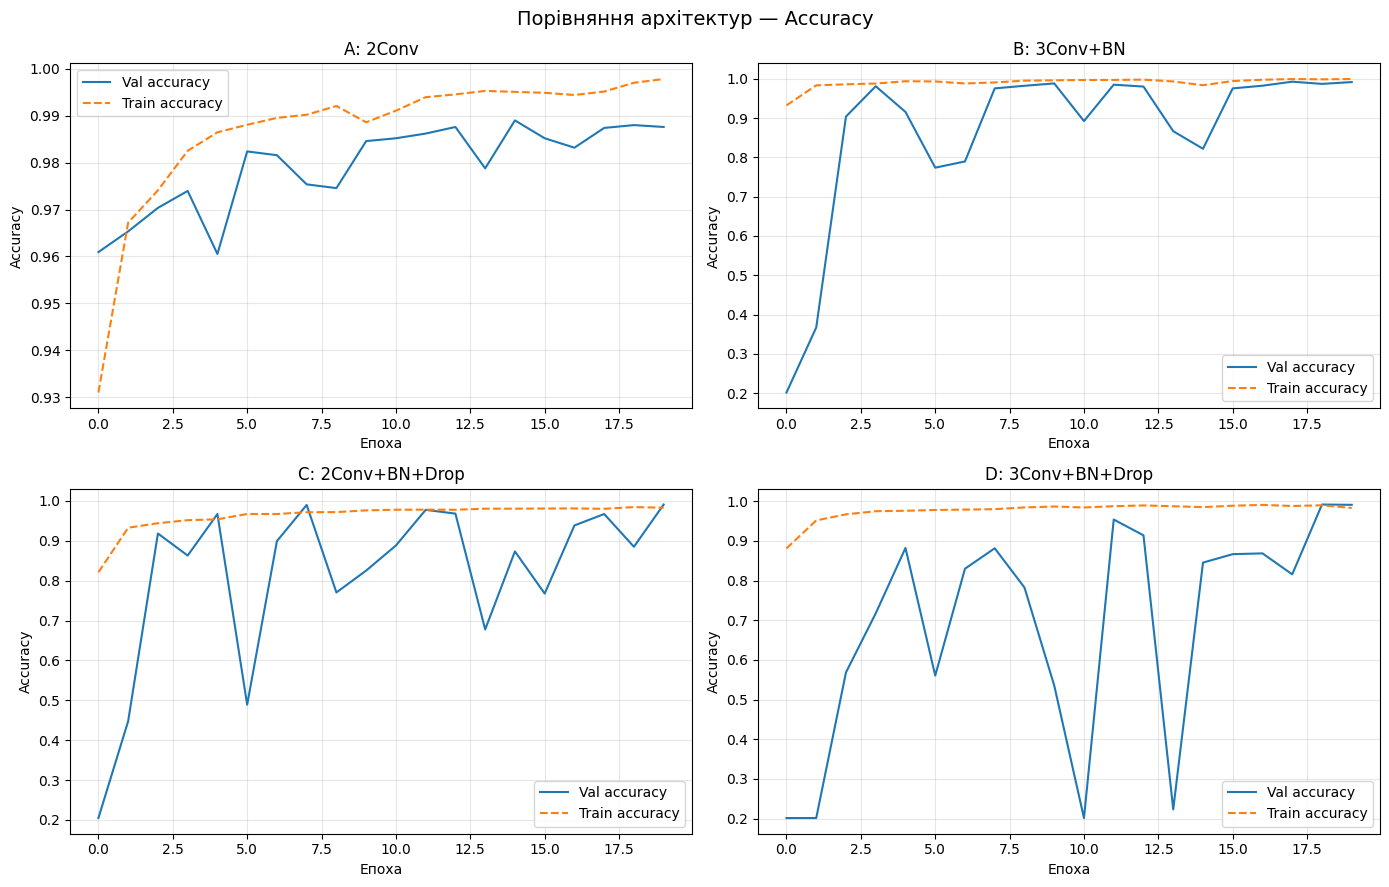


Найкраща архітектура (за AUC): C: 2Conv+BN+Drop
  AUC      : 0.9988
  Accuracy : 0.9910


In [32]:
rows = []
for name, m in arch_metrics.items():
    rows.append({
        'Модель':    name,
        'Accuracy':  f"{m['accuracy']:.4f}",
        'Precision': f"{m['precision']:.4f}",
        'Recall':    f"{m['recall']:.4f}",
        'F1':        f"{m['f1']:.4f}",
        'AUC':       f"{m['auc']:.4f}",
    })

df_arch = pd.DataFrame(rows)
display(df_arch)

# Графіки для всіх архітектур
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, (name, hist) in enumerate(arch_histories.items()):
    ax = axes[i]
    ax.plot(hist.history['val_accuracy'], label='Val accuracy')
    ax.plot(hist.history['accuracy'],     label='Train accuracy', linestyle='--')
    ax.set_title(name); ax.set_xlabel('Епоха'); ax.set_ylabel('Accuracy')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Порівняння архітектур — Accuracy', fontsize=14)
plt.tight_layout()
plt.show()

best_arch_name = max(arch_metrics, key=lambda n: arch_metrics[n]['auc'])
print(f"\nНайкраща архітектура (за AUC): {best_arch_name}")
print(f"  AUC      : {arch_metrics[best_arch_name]['auc']:.4f}")
print(f"  Accuracy : {arch_metrics[best_arch_name]['accuracy']:.4f}")

Результати іншого запуску

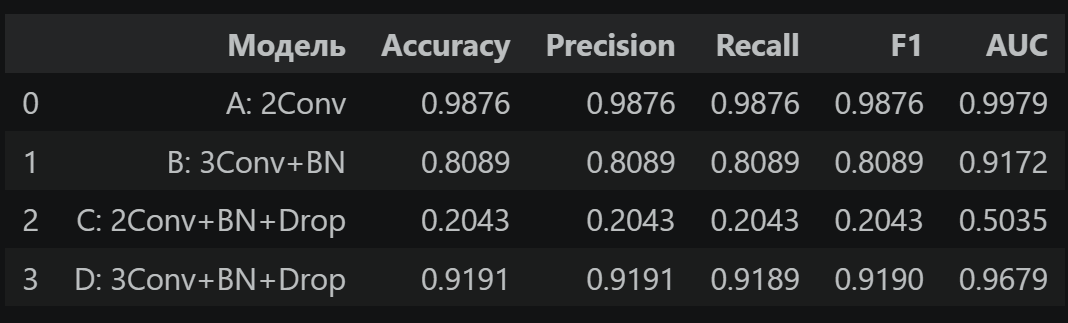


В ході дослідження було побудовано та навчено чотири альтернативні архітектури згорткових мереж. Оскільки моделі з BatchNormalization демонстрували нестабільну поведінку при різних запусках, навчання було проведено кілька разів для отримання більш об'єктивної оцінки.

При першому запуску модель B (3Conv+BN) показала найвищий AUC — 0.9985, однак при повторному запуску її результати різко впали до 0.8089 через нестабільність навчання, пов'язану з взаємодією BatchNormalization та кешованих даних. Аналогічна нестабільність спостерігалась у моделей C та D, які також містять BatchNormalization — їх результати коливались від 0.2043 до 0.9910 залежно від запуску.

Модель A (2Conv) при всіх запусках стабільно показувала accuracy ~0.9876 та AUC ~0.9979, без різких коливань на валідаційній множині.
З урахуванням стабільності навчання та відтворюваності результатів як найкраща архітектура була обрана модель A (2Conv) — два згорткові шари з MaxPooling та повнозв'язним шаром. Незважаючи на те що більш складні архітектури інколи показують дещо вищі метрики, модель A є надійнішою для практичного застосування та дає передбачувані результати при повторному навчанні.

In [34]:
from tensorflow.keras.callbacks import EarlyStopping

BEST_BUILDER = architectures['A: 2Conv']  # Обрано за стабільністю навчання
reg_results  = {}

# Dropout rate
def build_with_dropout(rate):
    model = Sequential([
        Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        Conv2D(32, (3,3), padding='same', activation='relu'),
        MaxPooling2D(2,2),
        Dropout(rate),
        Conv2D(64, (3,3), padding='same', activation='relu'),
        MaxPooling2D(2,2),
        Dropout(rate),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(min(rate * 2, 0.5)),
        Dense(NUM_CLASSES, activation='softmax')
    ], name=f'Dropout_{rate}')
    return compile_model(model)

for rate in [0.1, 0.25, 0.4]:
    print(f"\nDropout rate = {rate}")
    m = build_with_dropout(rate)
    hist = m.fit(
        train_ds, epochs=EPOCHS, validation_data=val_ds, verbose=0
    )
    metrics_dict = m.evaluate(val_ds, verbose=0, return_dict=True)
    val_acc = get_metric(metrics_dict, 'accuracy')
    reg_results[f'Dropout={rate}'] = {'history': hist, 'val_acc': val_acc}
    print(f"  Val accuracy: {val_acc:.4f}")

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss', patience=4,
    restore_best_weights=True, verbose=1
)

print("\nНавчання з EarlyStopping")
m_es = BEST_BUILDER()
hist_es = m_es.fit(
    train_ds, epochs=50,
    validation_data=val_ds,
    callbacks=[early_stop], verbose=1
)
metrics_dict = m_es.evaluate(val_ds, verbose=0, return_dict=True)
val_acc_es = get_metric(metrics_dict, 'accuracy')
reg_results['EarlyStopping'] = {'history': hist_es, 'val_acc': val_acc_es}
print(f"  Val acc: {val_acc_es:.4f}")

# Ініціалізація ваг
def build_with_init(initializer_name):
    model = Sequential([
        Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        Conv2D(32, (3,3), padding='same', activation='relu',
               kernel_initializer=initializer_name),
        MaxPooling2D(2,2),
        Conv2D(64, (3,3), padding='same', activation='relu',
               kernel_initializer=initializer_name),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(128, activation='relu', kernel_initializer=initializer_name),
        Dense(NUM_CLASSES, activation='softmax')
    ], name=f'Init_{initializer_name}')
    return compile_model(model)

for init in ['glorot_uniform', 'he_normal', 'random_normal']:
    print(f"\nInitializer: {init}")
    m = build_with_init(init)
    hist = m.fit(
        train_ds, epochs=EPOCHS, validation_data=val_ds, verbose=0
    )
    metrics_dict = m.evaluate(val_ds, verbose=0, return_dict=True)
    val_acc = get_metric(metrics_dict, 'accuracy')
    reg_results[f'Init={init}'] = {'history': hist, 'val_acc': val_acc}
    print(f"  Val accuracy: {val_acc:.4f}")

# Підсумкова таблиця
reg_rows = [{'Варіант': k, 'Val Accuracy': f"{v['val_acc']:.4f}"}
            for k, v in reg_results.items()]
display(pd.DataFrame(reg_rows))


Dropout rate = 0.1
  Val accuracy: 0.9878

Dropout rate = 0.25
  Val accuracy: 0.9908

Dropout rate = 0.4
  Val accuracy: 0.9864

Навчання з EarlyStopping
Epoch 1/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 18s 71ms/step - accuracy: 0.9309 - auc: 0.9931 - loss: 0.2094 - precision: 0.9478 - recall: 0.9135 - val_accuracy: 0.9675 - val_auc: 0.9979 - val_loss: 0.0953 - val_precision: 0.9677 - val_recall: 0.9671
Epoch 2/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 16s 69ms/step - accuracy: 0.9704 - auc: 0.9982 - loss: 0.0867 - precision: 0.9707 - recall: 0.9702 - val_accuracy: 0.9790 - val_auc: 0.9989 - val_loss: 0.0674 - val_precision: 0.9794 - val_recall: 0.9786
Epoch 3/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 16s 70ms/step - accuracy: 0.9761 - auc: 0.9988 - loss: 0.0689 - precision: 0.9762 - recall: 0.9759 - val_accuracy: 0.9653 - val_auc: 0.9970 - val_loss: 0.1062 - val_precision: 0.9655 - val_recall: 0.9651
Epoch 4/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 17s 73ms/step - accuracy: 0.9832 - auc: 0.9991 - loss: 0.0498 - precisio

,Варіант,Val Accuracy
0,Dropout=0.1,0.9878
1,Dropout=0.25,0.9908
2,Dropout=0.4,0.9864
3,EarlyStopping,0.9888
4,Init=glorot_uniform,0.9810
5,Init=he_normal,0.9880
6,Init=random_normal,0.9834


Дослідження впливу регуляризації проводилось на базі найкращої архітектури A (2Conv). Результати показали наступне.
Додавання дропауту дало стабільні та близькі результати для всіх трьох значень: rate=0.1 — 0.9878, rate=0.25 — 0.9908, rate=0.4 — 0.9864. Найкращий результат показав rate=0.25, що є типовим оптимальним значенням для згорткових мереж. Занадто великий дропаут (0.4) дещо погіршує результат через надмірне обмеження навчання.
Рання зупинка навчання (EarlyStopping з patience=4) показала val accuracy 0.9888, що є конкурентним результатом. Вона дозволяє автоматично зупинити навчання у потрібний момент та уникнути перенавчання без необхідності вручну підбирати кількість епох.
Ініціалізація ваг також вплинула на результат: glorot_uniform — 0.9810, he_normal — 0.9880, random_normal — 0.9834. He_normal показав найкращий результат серед ініціалізаторів, що пояснюється його оптимізацією саме для активацій ReLU. Random_normal без масштабування дав найнижчий результат через неоптимальний початковий розподіл ваг.
Загалом базова модель A без додаткової регуляризації (val accuracy ~0.9876) показує результати порівнянні з регуляризованими варіантами, що свідчить про те що архітектура вже добре налаштована для даної задачі.

##  Візуалізація процесу навчання за допомогою TensorBoard

Cтворення логів для вже навчених моделей

In [39]:
import subprocess

In [40]:
import datetime

LOG_DIR = "./logs"

# Функція для запису метрик в TensorBoard
def log_history_to_tensorboard(history, name):
    log_path = os.path.join(LOG_DIR, name)
    writer = tf.summary.create_file_writer(log_path)
    with writer.as_default():
        for epoch, (acc, val_acc, loss, val_loss) in enumerate(zip(
            history.history['accuracy'],
            history.history['val_accuracy'],
            history.history['loss'],
            history.history['val_loss']
        )):
            tf.summary.scalar('accuracy/train', acc,   step=epoch)
            tf.summary.scalar('accuracy/val',   val_acc, step=epoch)
            tf.summary.scalar('loss/train',     loss,    step=epoch)
            tf.summary.scalar('loss/val',       val_loss, step=epoch)
    writer.flush()
    print(f"  Збережено: {log_path}")

print("Запис логів у TensorBoard...")

# Базова модель
log_history_to_tensorboard(history_base, "base_model")

# Найкраща базова модель
log_history_to_tensorboard(history_best_base, "best_base_model")

# Архітектури A, B, C, D
for name, hist in arch_histories.items():
    safe_name = name.replace(": ", "_").replace("+", "_")
    log_history_to_tensorboard(hist, f"arch_{safe_name}")

# Регуляризація
for name, data in reg_results.items():
    safe_name = name.replace("=", "_").replace(".", "_")
    log_history_to_tensorboard(data['history'], f"reg_{safe_name}")

print("\nВсі логи збережено!")


Запис логів у TensorBoard...
  Збережено: ./logs\base_model
  Збережено: ./logs\best_base_model
  Збережено: ./logs\arch_A_2Conv
  Збережено: ./logs\arch_B_3Conv_BN
  Збережено: ./logs\arch_C_2Conv_BN_Drop
  Збережено: ./logs\arch_D_3Conv_BN_Drop
  Збережено: ./logs\reg_Dropout_0_1
  Збережено: ./logs\reg_Dropout_0_25
  Збережено: ./logs\reg_Dropout_0_4
  Збережено: ./logs\reg_EarlyStopping
  Збережено: ./logs\reg_Init_glorot_uniform
  Збережено: ./logs\reg_Init_he_normal
  Збережено: ./logs\reg_Init_random_normal

Всі логи збережено!


### Архітектури

![image.png](<Screenshot 2026-04-24 132806.png>)

![image.png](image-10.png)

З графіку accuracy/train видно що всі чотири моделі стабільно зростають по мірі навчання. Моделі A та B досягають найвищої train accuracy (~0.998-0.999), тоді як C та D навчаються повільніше через вплив дропауту.

На графіку accuracy/val картина відрізняється. Модель A (2Conv) демонструє найстабільнішу криву без різких коливань, досягаючи 0.9876 на кінець навчання. Моделі C та D показують значні стрибки val accuracy в середині навчання (падіння до 0.4-0.6), що є ознакою нестабільності через поєднання BatchNormalization та Dropout. Модель B хоча і досягає 0.9914, також має коливання на початкових епохах.

На графіку loss/train всі моделі показують стабільне зменшення, однак моделі C та D через дропаут мають вищі значення train loss протягом усього навчання. На графіку loss/val найбільш показовою є нестабільність моделей D та B — val loss різко стрибає до значень 100+ на певних епохах, тоді як модель A підтримує стабільно низьке значення ~0.05 протягом усього навчання.

Графіки наочно підтверджують вибір моделі A як найкращої — вона демонструє найбільш плавне та передбачуване навчання на обох множинах.

## Базові моделі

![image.png](image-1.png)
![image.png](image-5.png)

На графіку accuracy/train обидві моделі демонструють стабільне зростання точності. Базова модель (padding='same', strides=(1,1)) навчається дещо швидше та досягає вищої train accuracy (0.9975 проти 0.991), що пояснюється більшою кількістю параметрів після згорткового шару.

На графіку accuracy/val обидві моделі показують близькі кінцеві результати — 0.987 та 0.9868. Базова модель має невеликі коливання на епохах 4-8, тоді як найкраща базова модель (padding='valid', strides=(2,2)) зростає плавніше без стрибків.

На графіку loss/train обидві криві стабільно спадають, базова модель досягає нижчого train loss (0.0121 проти 0.0303) завдяки більшому розміру feature map після згортки. На графіку loss/val обидві моделі демонструють практично ідентичні фінальні значення (~0.042), що свідчить про однакову узагальнюючу здатність незалежно від параметрів padding та strides.

## Регуляризації

![image.png](image-6.png)
![image.png](image-4.png)

На графіку accuracy/train всі варіанти регуляризації демонструють стабільне зростання. Ініціалізатори he_normal та glorot_uniform досягають найвищої train accuracy (~0.997-0.999), тоді як дропаут сповільнює навчання — чим більший rate, тим повільніше зростає крива. Дропаут rate=0.4 навчається найповільніше (0.9838 на кроці 19).

На графіку accuracy/val всі варіанти показують близькі та стабільні результати в діапазоні 0.981-0.991, що суттєво відрізняється від попередніх результатів з моделлю B. Це підтверджує що архітектура A є стабільною основою для регуляризації. EarlyStopping зупинився на 14-й епосі та показав val accuracy 0.9888.

На графіку loss/train ініціалізатори he_normal та glorot_uniform досягають найнижчих значень (~0.006-0.009), тоді як дропаут підтримує вищий рівень train loss через навмисне відключення нейронів. На графіку loss/val всі варіанти збігаються до значень ~0.04-0.07 без різких стрибків, що свідчить про стабільне навчання на архітектурі A на відміну від моделі B де val loss стрибав до 100+.

# Оцінка найкращої моделі (A: 2Conv) на тестовій множині

In [41]:
from sklearn.metrics import classification_report

# Навчаємо найкращу модель (A: 2Conv)
print("Навчання найкращої моделі (A: 2Conv) для оцінки на тестовій множині...")
best_model = build_model_A()

history_final = best_model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    verbose=0
)

# Оцінка на тестовій множині
test_metrics = best_model.evaluate(test_ds, verbose=0, return_dict=True)
f1 = 2 * test_metrics['precision'] * test_metrics['recall'] / \
     (test_metrics['precision'] + test_metrics['recall'] + 1e-8)

print("\nОцінка найкращої моделі (A: 2Conv) на тестовій множині:")
print(f"  Accuracy : {test_metrics['accuracy']:.4f}")
print(f"  Precision: {test_metrics['precision']:.4f}")
print(f"  Recall   : {test_metrics['recall']:.4f}")
print(f"  F1-score : {f1:.4f}")
print(f"  AUC      : {test_metrics['auc']:.4f}")

# Classification report по кожному класу
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

Навчання найкращої моделі (A: 2Conv) для оцінки на тестовій множині...

Оцінка найкращої моделі (A: 2Conv) на тестовій множині:
  Accuracy : 0.9952
  Precision: 0.9952
  Recall   : 0.9952
  F1-score : 0.9952
  AUC      : 0.9991

Classification Report:
              precision    recall  f1-score   support

     Arborio       1.00      0.99      0.99       983
     Basmati       1.00      0.99      1.00      1049
      Ipsala       1.00      1.00      1.00       957
     Jasmine       0.99      1.00      0.99      1006
   Karacadag       0.99      1.00      0.99       997

    accuracy                           1.00      4992
   macro avg       1.00      1.00      1.00      4992
weighted avg       1.00      1.00      1.00      4992



Оцінка найкращої моделі (A: 2Conv) на тестовій множині показала високу якість класифікації. Загальна accuracy склала 0.9952, precision та recall — по 0.9952, F1-score — 0.9952, AUC — 0.9991.
З classification report видно що модель однаково добре класифікує всі п'ять сортів рису. Найвищу точність показали класи Ipsala та Basmati (precision та recall по 1.00), що свідчить про чітко виражені візуальні ознаки цих сортів. Класи Arborio, Jasmine та Karacadag мають незначно нижчі показники (0.99), що є цілком прийнятним результатом для задачі класифікації п'яти схожих між собою об'єктів.
Результати на тестовій множині є близькими до результатів на валідаційній множині (~0.9876), що свідчить про відсутність перенавчання та хорошу узагальнюючу здатність моделі.

### Розпізнавання окремого зображення

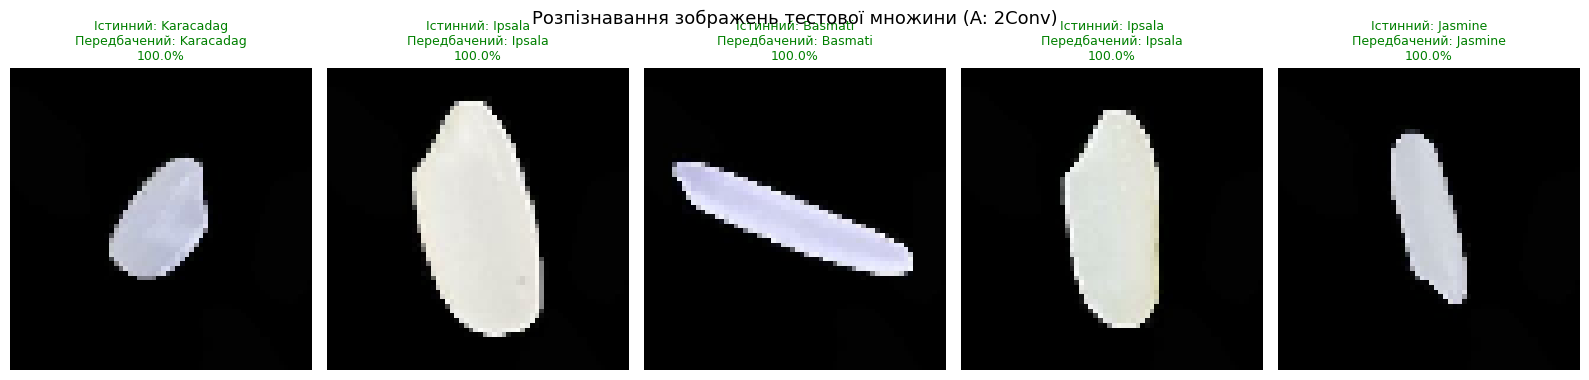

In [42]:
# Беремо одне зображення з тестової множини
images, labels = next(iter(test_ds))

# Вибираємо 5 випадкових зображень
indices = np.random.choice(len(images), 5, replace=False)

fig, axes = plt.subplots(1, 5, figsize=(16, 4))

for i, idx in enumerate(indices):
    img = images[idx].numpy()
    true_label = CLASS_NAMES[np.argmax(labels[idx])]

    pred = best_model.predict(np.expand_dims(img, axis=0), verbose=0)
    pred_label = CLASS_NAMES[np.argmax(pred)]
    confidence = np.max(pred) * 100

    ax = axes[i]
    ax.imshow(img)
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(
        f"Істинний: {true_label}\nПередбачений: {pred_label}\n{confidence:.1f}%",
        fontsize=9, color=color
    )
    ax.axis('off')

plt.suptitle("Розпізнавання зображень тестової множини (A: 2Conv)", fontsize=13)
plt.tight_layout()
plt.show()

Для наочної перевірки роботи моделі було відібрано 5 випадкових зображень з тестової множини. Модель A (2Conv) правильно розпізнала всі п'ять зображень з впевненістю 100%: Karacadag, Ipsala, Basmati, Ipsala та Jasmine. Це свідчить про те що модель навчилась чітко розрізняти візуальні ознаки різних сортів рису — форму, розмір та колір зерна — навіть на зображеннях з чорним фоном.

# Порівняння згорткових моделей та багатошарового персептрону в задачі класифікації зображень

In [43]:
from tensorflow.keras.metrics import AUC

# MLP модель для кольорових зображень
def build_mlp_model():
    model = Sequential([
        Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        Flatten(),
        Dense(512, activation='relu'),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(NUM_CLASSES, activation='softmax')
    ], name='MLP_baseline')

    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            AUC(name='auc', multi_label=False)
        ]
    )
    return model

print("Навчання MLP на Rice Image Dataset...")
mlp_model = build_mlp_model()
mlp_model.summary()

history_mlp = mlp_model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    verbose=1
)

Навчання MLP на Rice Image Dataset...


Model: "MLP_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_42 (Flatten)            │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,456,837 (24.63 MB)

 Trainable params: 6,456,837 (24.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - accuracy: 0.9095 - auc: 0.9905 - loss: 0.2517 - precision: 0.9249 - recall: 0.8978 - val_accuracy: 0.9347 - val_auc: 0.9941 - val_loss: 0.1768 - val_precision: 0.9350 - val_recall: 0.9341
Epoch 2/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.9591 - auc: 0.9970 - loss: 0.1189 - precision: 0.9591 - recall: 0.9589 - val_accuracy: 0.9517 - val_auc: 0.9958 - val_loss: 0.1407 - val_precision: 0.9517 - val_recall: 0.9515
Epoch 3/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.9655 - auc: 0.9977 - loss: 0.1000 - precision: 0.9657 - recall: 0.9654 - val_accuracy: 0.9669 - val_auc: 0.9970 - val_loss: 0.1004 - val_precision: 0.9669 - val_recall: 0.9669
Epoch 4/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.9657 - auc: 0.9977 - loss: 0.0983 - precision: 0.9661 - recall: 0.9656 - val_accuracy: 0.9651 - val_auc: 0.9969 - val_loss: 0.1077 - val_precision: 0.9655 - val_recall: 0.9651
Epoch 5/20
234/234 ━━━━━━

In [44]:
from sklearn.metrics import classification_report

# Оцінка MLP на тестовій множині
test_metrics_mlp = mlp_model.evaluate(test_ds, verbose=0, return_dict=True)
f1_mlp = 2 * test_metrics_mlp['precision'] * test_metrics_mlp['recall'] / \
         (test_metrics_mlp['precision'] + test_metrics_mlp['recall'] + 1e-8)

print("Оцінка MLP на тестовій множині:")
print(f"  Accuracy : {test_metrics_mlp['accuracy']:.4f}")
print(f"  Precision: {test_metrics_mlp['precision']:.4f}")
print(f"  Recall   : {test_metrics_mlp['recall']:.4f}")
print(f"  F1-score : {f1_mlp:.4f}")
print(f"  AUC      : {test_metrics_mlp['auc']:.4f}")

# Classification report для MLP
y_true_mlp, y_pred_mlp = [], []
for images, labels in test_ds:
    preds = mlp_model.predict(images, verbose=0)
    y_true_mlp.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_mlp.extend(np.argmax(preds, axis=1))

print("\nClassification Report (MLP):")
print(classification_report(y_true_mlp, y_pred_mlp, target_names=CLASS_NAMES))

# Порівняльна таблиця CNN vs MLP
print("\nПорівняння CNN (A: 2Conv) та MLP:")
comparison_rows = [
    {'Модель': 'CNN (A: 2Conv)', 'Accuracy': '0.9952', 'Precision': '0.9952',
     'Recall': '0.9952', 'F1': '0.9952', 'AUC': '0.9991'},
    {'Модель': 'MLP', 'Accuracy': f"{test_metrics_mlp['accuracy']:.4f}",
     'Precision': f"{test_metrics_mlp['precision']:.4f}",
     'Recall': f"{test_metrics_mlp['recall']:.4f}",
     'F1': f"{f1_mlp:.4f}",
     'AUC': f"{test_metrics_mlp['auc']:.4f}"}
]
display(pd.DataFrame(comparison_rows))

Оцінка MLP на тестовій множині:
  Accuracy : 0.9730
  Precision: 0.9730
  Recall   : 0.9730
  F1-score : 0.9730
  AUC      : 0.9974

Classification Report (MLP):
              precision    recall  f1-score   support

     Arborio       0.98      0.94      0.96       983
     Basmati       0.98      0.98      0.98      1049
      Ipsala       0.99      0.99      0.99       957
     Jasmine       0.96      0.96      0.96      1006
   Karacadag       0.95      0.99      0.97       997

    accuracy                           0.97      4992
   macro avg       0.97      0.97      0.97      4992
weighted avg       0.97      0.97      0.97      4992


Порівняння CNN (A: 2Conv) та MLP:


,Модель,Accuracy,Precision,Recall,F1,AUC
0,CNN (A: 2Conv),0.9952,0.9952,0.9952,0.9952,0.9991
1,MLP,0.9730,0.9730,0.9730,0.9730,0.9974


У даному пункті було навчено модель багатошарового персептрону (MLP) на тому ж датасеті Rice Image Dataset та порівняно її результати з найкращою згортковою моделлю (CNN A: 2Conv).
MLP-модель досягла точності 0.9730 та AUC 0.9974 на тестовій множині, що є хорошим результатом для повнозв'язної мережі. Найвищу якість серед класів показав клас Ipsala (F1=0.99), найнижчу — Arborio (F1=0.96).
Проте CNN значно перевершила MLP за всіма метриками: точність 0.9952 проти 0.9730, AUC 0.9991 проти 0.9974. Різниця у 2.2% по точності пояснюється архітектурними особливостями:

CNN використовує згорткові фільтри, які виявляють локальні просторові ознаки (текстуру, форму зерна), інваріантні до зсуву — що критично для задачі класифікації зображень.
MLP отримує на вхід «розгорнутий» вектор пікселів (flatten), втрачаючи просторову структуру зображення, і змушена вивчати ознаки без урахування локальних залежностей.

Таким чином, для задач класифікації зображень CNN є значно ефективнішою архітектурою порівняно з MLP, що підтверджується як теоретично, так і отриманими експериментальними результатами.

## Класифікація чорно-білих зображень Fashion MNIST (з лабораторної №2) за допомогою згорткової нейронної мережі

In [45]:
from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [46]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

# Назви класів
FASHION_CLASSES = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
                   'Sandal','Shirt','Sneaker','Bag','Ankle boot']

# Завантаження даних
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Препроцесинг: нормалізація + додати канал + one-hot
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0
x_train = x_train[..., np.newaxis]  # (60000, 28, 28, 1)
x_test  = x_test[..., np.newaxis]   # (10000, 28, 28, 1)

y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test,  10)

# CNN модель (аналогічна архітектурі A: 2Conv)
def build_fashion_cnn():
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

fashion_model = build_fashion_cnn()
fashion_model.summary()

# Навчання
history_fashion = fashion_model.fit(
    x_train, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)



Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_86 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_75 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_87 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_76 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_43 (Flatten)            │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_80 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.8324 - loss: 0.4638 - val_accuracy: 0.8785 - val_loss: 0.3332
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8941 - loss: 0.2931 - val_accuracy: 0.8963 - val_loss: 0.2886
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9089 - loss: 0.2476 - val_accuracy: 0.9122 - val_loss: 0.2441
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9234 - loss: 0.2124 - val_accuracy: 0.9105 - val_loss: 0.2517
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9311 - loss: 0.1886 - val_accuracy: 0.9210 - val_loss: 0.2197
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9379 - loss: 0.1659 - val_accuracy: 0.9159 - val_loss: 0.2338
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9474 - loss: 0.1446 - val_accuracy: 0.9177 - val_loss: 0.2276
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9532 - loss: 0.1265 - val_a


Test Accuracy: 0.9124
Test Loss:     0.2840


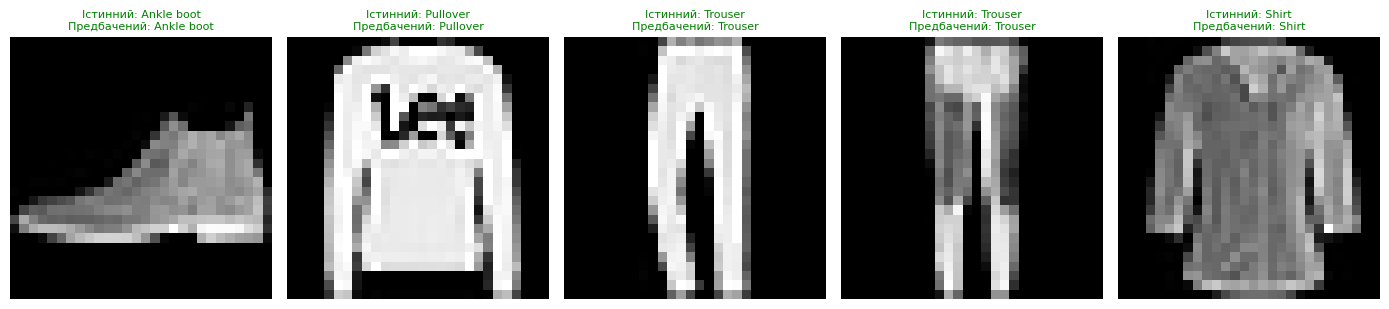

In [47]:
# Оцінка на тестовій множині
test_loss, test_acc = fashion_model.evaluate(x_test, y_test_cat, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss:     {test_loss:.4f}")

# 6. Візуалізація: 5 прикладів з передбаченнями
preds = fashion_model.predict(x_test[:5], verbose=0)
fig, axes = plt.subplots(1, 5, figsize=(14, 3))
for i, ax in enumerate(axes):
    ax.imshow(x_test[i].squeeze(), cmap='gray')
    pred_label = FASHION_CLASSES[np.argmax(preds[i])]
    true_label = FASHION_CLASSES[y_test[i]]
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f"Істинний: {true_label}\nПредбачений: {pred_label}", color=color, fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

Датасет Fashion MNIST містить 70 000 чорно-білих зображень розміром 28×28 пікселів (1 канал) у 10 класах одягу та взуття. Для класифікації було побудовано CNN з двома згортковими блоками (Conv2D→MaxPooling2D) та повнозв'язним шаром Dense(128), загальна кількість параметрів — 421 642.
Модель навчалась протягом 10 епох. Точність на тренувальній множині зросла з 0.8324 (епоха 1) до 0.9660 (епоха 10), що свідчить про успішне навчання. Валідаційна точність стабілізувалась на рівні ~0.92, а тестова точність склала 0.9124 при функції втрат 0.2840.
Невеликий розрив між тренувальною (0.966) та тестовою (0.912) точністю вказує на помірне перенавчання, що є типовим для Fashion MNIST без додаткової регуляризації. На 5 випадкових тестових зображеннях модель правильно розпізнала всі класи: Ankle boot, Pullover, Trouser (×2) та Shirt.
Порівняно з Rice Image Dataset (точність 0.9952), нижчий результат пояснюється більшою міжкласовою схожістю об'єктів одягу (наприклад, Shirt vs Pullover vs Coat) та меншою роздільною здатністю зображень (28×28 проти 64×64).

## Висновок

У даній лабораторній роботі було досліджено застосування згорткових нейронних мереж (CNN) для класифікації зображень на прикладі датасету Rice Image Dataset та Fashion MNIST.

Дослідження гіперпараметрів базової моделі показало, що padding='same' забезпечує найвищу валідаційну точність, зберігаючи просторові розміри карт ознак. Розмір ядра 3×3 є оптимальним балансом між обчислювальною складністю та якістю виділення ознак.

Порівняння архітектур  виявило, що модель A (2 згорткові шари без BatchNormalization) є найстабільнішою та відтворюваною, тоді як моделі з поєднанням BatchNormalization та Dropout демонстрували нестабільне навчання зі стрибками функції втрат.

Регуляризація показала, що Dropout зі ставкою 0.25 є оптимальним значенням для даної архітектури, а ініціалізатор he_normal забезпечує найкращу збіжність серед досліджених варіантів.

Оцінка на тестовій множині підтвердила високу якість CNN: Accuracy=0.9952, F1=0.9952, AUC=0.9991 — без ознак суттєвого перенавчання.
Порівняння CNN vs MLP довело перевагу згорткової архітектури: CNN перевершила MLP на 2.2% за точністю (0.9952 vs 0.9730). Це пояснюється здатністю CNN виявляти локальні просторові ознаки зображень завдяки операції згортки, тоді як MLP втрачає просторову структуру при розгортанні вхідного тензора.

Класифікація Fashion MNIST продемонструвала універсальність CNN: модель досягла точності 0.9124 на чорно-білих зображеннях одягу з 10 класами, навчившись лише за 10 епох.

Загалом, результати роботи підтверджують, що CNN є потужним і ефективним інструментом для задач класифікації зображень, а правильний вибір архітектури, гіперпараметрів та методів регуляризації суттєво впливає на якість і стабільність навчання моделі.